In [323]:
import pandas as pd
import matplotlib.pyplot as plt

In [325]:
eggs_df = []
for i in range(2022, 2026):
    eggs_df.append(pd.read_excel('nedel_Ipc (1).xlsx', sheet_name = f'{i}'))
ipc_df = pd.read_excel('ipc_mes_02-2025.xlsx', sheet_name = '01')

In [326]:
eggs_dict = {}
for i in range(4):
    eggs_df[i].index = eggs_df[i]['К содержанию']
    eggs_df[i]['К содержанию'] = str(2022 + i)
    eggs_dict[eggs_df[i].loc['Яйца куриные, 10 шт.', 'К содержанию']] = eggs_df[i].loc['Яйца куриные, 10 шт.'].iloc[1:]

In [327]:
ipc_df = ipc_df.iloc[4:16]
ipc_df = ipc_df.iloc[:, -4:]
ipc_df =ipc_df.reset_index(drop = True)

In [328]:
eggs_y = []
ipc_y = []
for i in range(2022, 2026):
    eggs_y += list(eggs_dict[f'{i}'])
for i in range(3):
    ipc_y += list(ipc_df.iloc[:, i])
ipc_y += list(ipc_df.iloc[:2, 3])

In [329]:
eggs_y[0] /= 100
ipc_y[0] /= 100
for i in range(1, len(eggs_y)):
    eggs_y[i] *= (eggs_y[i - 1] / 100)
    
for i in range(1, len(ipc_y)):
    ipc_y[i] *= ipc_y[i - 1] / 100


In [330]:
eggs_x_year = [9 + 7 * i for i in range(51)] # это кол-во дней, прошедших с начала года до каждого измерения росстата
eggs_x = [] # это кол-во дней, прошедших с начала 2022 года до каждого измерения росстата
for i in range(3):
    eggs_x += [day + 365*i for day in eggs_x_year]
eggs_x += [day + 365*3 for day in eggs_x_year[:11]]

In [331]:
ipc_x_year = [30 + 30 * i for i in range(12)]
ipc_x = []
for i in range(3):
    ipc_x += [day + 365*i for day in ipc_x_year]
ipc_x += [day + 365*3 for day in eggs_x_year[:2]]
len(ipc_x)

38

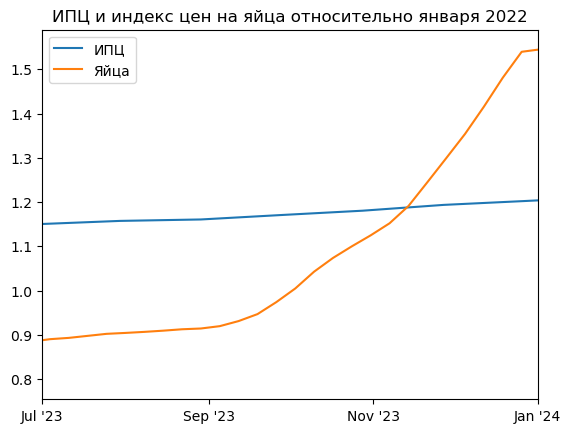

In [345]:

plt.plot(ipc_x, ipc_y, label = 'ИПЦ')
plt.plot(eggs_x, eggs_y, label = 'Яйца')
plt.xlim(550, 730)
plt.xticks(ticks=[546, 608, 669, 730], labels=['Jul \'23', 'Sep \'23', 'Nov \'23', 'Jan \'24'])
plt.title('ИПЦ и индекс цен на яйца относительно января 2022')
plt.legend()
plt.show()